# Удаление артефактов, ICA

В этом ноутбуке мы познакомимся поближе с такими темами, как:

- Артефакты в ЭЭГ
- Метод главных компонент (PCA)
- Метод независимых компонент (ICA)
- Signal-to-Noise Ratio (SNR)

В конце ноутбука будет конспект по всем темам с полезными ссылками для дополнительного чтения

---

### 0. Загрузка данных

In [ ]:
!pip install mne==1.11.0 >> logs.txt

In [ ]:
import mne
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

%matplotlib inline

In [ ]:
# Путь к sample-датасету (если данных нет, они автоматически скачаются)
sample_data_folder = mne.datasets.sample.data_path()
raw_path = os.path.join(
    sample_data_folder,
    "MEG",
    "sample",
    "sample_audvis_raw.fif",
)

In [ ]:
raw = mne.io.read_raw_fif(raw_path, preload=True).crop(tmax=60)

### 1. Артефакты в ЭЭГ

Артефакты в ЭЭГ — это нежелательные сигналы, регистрируемые при ЭЭГ и не связанные с мозговой активностью. Чаще всего они делятся на:
- физиологические (активность глаз, мышц, сердца и тд.)
- физические (сетевая наводка 50/60 Гц, движение электродов и тд.)

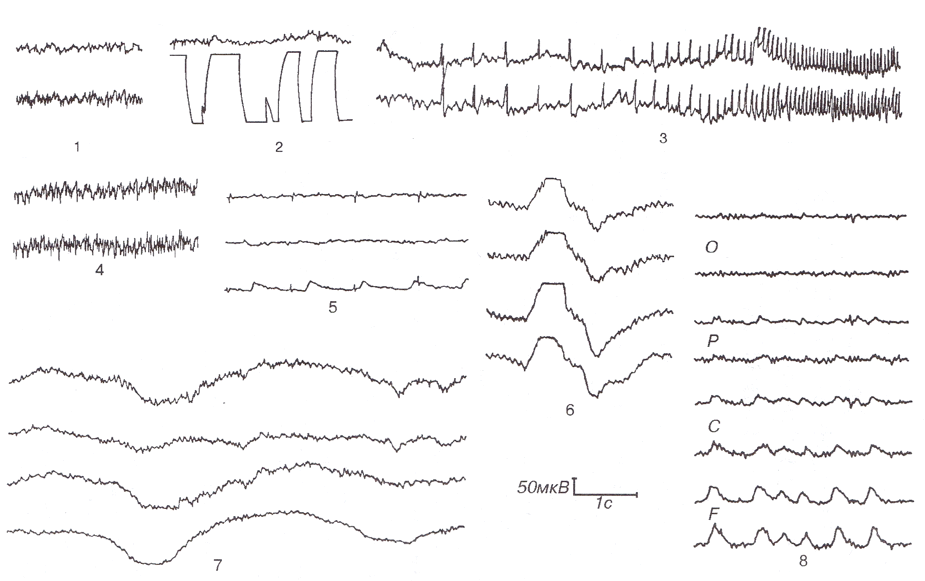

Некоторые основные типы артефактов в ЭЭГ. Источник: [CMI Brain Research](https://cmi.to/%D0%B0%D1%80%D1%82%D0%B5%D1%84%D0%B0%D0%BA%D1%82%D1%8B/)
- 1 — наводка сетевого тока частотой 50 Гц на нижнем канале;
- 2 — артефакты движения электрода на нижнем канале;
- 3 — артефакты от лампы фотостимулятора, повторяющие нарастающую частоту стимуляции;
- 4 — электромиограмма, накладывающаяся на ЭЭГ;
- 5 — артефакт ЭКГ (верхний канал) и пульсация сосуда под электродом (нижний канал);
- 6 — артефакт потенциала, связанного с глотательным движением;
- 7 — артефакт электрокожного потенциала;
- 8 — артефакт от движения глаз, максимально выраженный в лобных отведениях F

#### Основные типы физических артефактов:

1. **Проблемы с электродом**
- Частота: широкий спектр
- Каналы: все
- Признаки: отсутствие сигнала или какой-то шум с большими скачками
- Методы устранения: пометка bad channels


In [ ]:
raw.info['bads']

In [ ]:
raw.plot(duration=20, n_channels=2, picks=['EEG 053'], scalings='auto');

In [ ]:
# Авто-разметка артефактов по амплитуде

raw_ann = raw.copy()

ptp_threshold = {
    'mag': 4e-13,
    'grad': 4000e-13,
    'eog': 250e-7,
    'eeg': 50e-7
}

annotations, bad_channels = mne.preprocessing.annotate_amplitude(
    raw_ann,
    peak=ptp_threshold,
)

raw_ann.set_annotations(annotations, emit_warning=False)

# Добавляем bad каналы
raw_ann.info['bads'].extend(bad_channels)
print(f"Bad каналы: {bad_channels}")

2. **Сетевая наводка**
- Частота: `50/60 Гц`
- Каналы: все
- Признаки: регулярные колебания правильной синусоидной формы частотой 50 Гц в России и СНГ или 60 Гц в некоторых странах (например, США)
- Методы устранения: Notch filter на 50/60 Гц


In [ ]:
fig = raw.compute_psd(tmax=np.inf, fmax=250).plot(
    average=True, amplitude=False, picks="grad", exclude="bads"
)
# add some arrows at 60 Hz and its harmonics:
for ax in fig.axes[:]:
    freqs = ax.lines[-1].get_xdata()
    psds = ax.lines[-1].get_ydata()
    for freq in (60, 120, 180, 240):
        idx = np.searchsorted(freqs, freq)
        ax.arrow(
            x=freqs[idx],
            y=psds[idx] + 18,
            dx=0,
            dy=-12,
            color="red",
            width=0.1,
            head_width=3,
            length_includes_head=True,
        )

In [ ]:
fig = raw.copy().notch_filter(freqs=[60,120,180,240]).compute_psd(tmax=np.inf, fmax=250).plot(
    average=True, amplitude=False, picks="grad", exclude="bads"
);

#### Основные типы физиологических артефактов:

1. **Движение тела**
- Частота: широкий спектр
- Каналы: все
- Признаки: резкие скачки по амплитуде
- Методы устранения: reject bad epochs

In [ ]:
events = mne.find_events(raw, stim_channel="STI 014")

event_id = {
    "auditory/left": 1,
    "auditory/right": 2,
    "visual/left": 3,
    "visual/right": 4,
}

reject_criteria = {
    'mag': 4e-12,
    'grad': 4000e-13,
    'eog': 250e-6,
    'eeg': 500e-6
}

epochs = mne.Epochs(
    raw,
    events=events,
    event_id=event_id,
    tmin=-0.2,
    tmax=0.5,
    baseline=(-0.2, 0),
    preload=True,
    reject=reject_criteria,  # Отбрасывает epochs с артефактами
    reject_tmin=-0.1, reject_tmax=0.3, # Только в этом окне проверяем
)

In [ ]:
total_epochs = len(epochs.drop_log)
rejected_epochs = sum(1 for log in epochs.drop_log if (len(log) > 0 and 'IGNORED' not in log))
rejected_percent = (rejected_epochs / total_epochs) * 100

print(f"Всего epochs: {total_epochs}")
print(f"Отклонено: {rejected_epochs} ({rejected_percent:.1f}%)")

2. **Мышцы (ЭМГ)**
- Частота: `>30 Гц`
- Каналы: фронтальные и виски
- Признаки: высокочастотный шум
- Методы устранения: фильтр >40 Гц

In [ ]:
raw_bp = raw.copy().filter(l_freq=1, h_freq=40, picks='eeg')

3. **Глаза (ЭОГ)**

- Частота: `<4 Гц`
- Каналы: фронтальные, например, `Fp1/Fp2`
- Признаки: резкие пики
- Методы устранения: ICA

In [ ]:
eog_epochs = mne.preprocessing.create_eog_epochs(raw, picks='eeg', baseline=(-0.5, -0.2))
eog_epochs.plot_image(combine="mean")
eog_epochs.average().plot_joint();

4. **Сердце (ЭКГ)**
- Частота: `~1 Гц`
- Каналы: все
- Признаки: ритмичные пики, похожие на ЭКГ
- Методы устранения: ICA

In [ ]:
ecg_epochs = mne.preprocessing.create_ecg_epochs(raw, picks='grad')
ecg_epochs.plot_image(combine="mean");

#### Полезные ссылки:

- Подробно про типы артефактов в ЭЭГ: https://cmi.to/%D0%B0%D1%80%D1%82%D0%B5%D1%84%D0%B0%D0%BA%D1%82%D1%8B/
- Overview of artifact detection: https://mne.tools/stable/auto_tutorials/preprocessing/10_preprocessing_overview.html
- Repairing artifacts with SSP: https://mne.tools/stable/auto_tutorials/preprocessing/50_artifact_correction_ssp.html
- Repairing artifacts with regression: https://mne.tools/stable/auto_tutorials/preprocessing/35_artifact_correction_regression.html

### 2. Метод главных компонент (PCA)

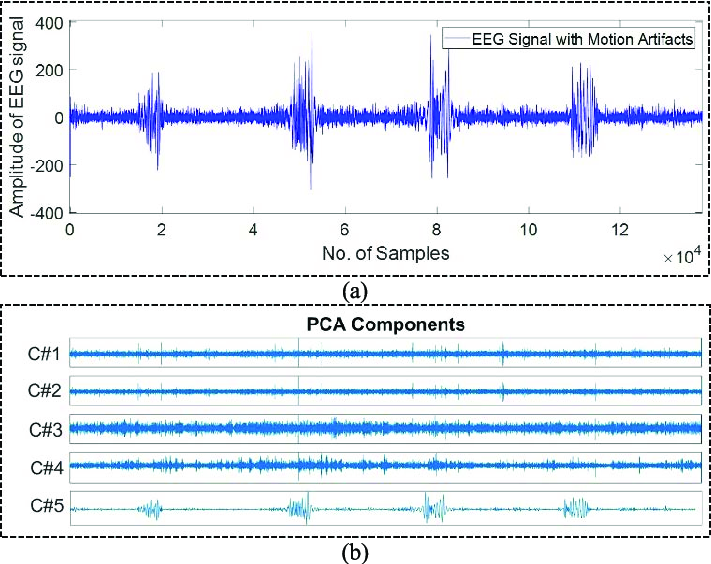

Источник: [Motion Artifacts Correction from EEG and fNIRS Signals using Novel Multiresolution Analysis](https://www.researchgate.net/figure/a-An-example-motion-corrupted-EEG-signal-and-b-corresponding-5-components-generated_fig4_359180454)

**Метод главных компонент (Principal Component Analysis)** — это метод снижения размерности, который можно использовать и для удаления артефактов, так как он:

- Находит коррелированные компоненты между каналами
- Сортирует их по важности (дисперсии)
- Позволяет удалить артефакты (чаще всего последние компоненты по важности), сохранив мозговую активность
- Используется как первый шаг в ICA

Примеры применения в ЭЭГ:

1. Удаление артефактов (ЭОГ, ЭМГ)
2. Сжатие данных (60 каналов -> 10 главных компонент)
3. Выделение пространственных паттернов

Пример, при загрузке sample данных мы видим:

```
Read a total of 3 projection items:
    PCA-v1 (1 x 102)  idle
    PCA-v2 (1 x 102)  idle  
    PCA-v3 (1 x 102)  idle
```

Это предвычисленные проекции на основе PCA с помощью `mne.compute_proj_raw()`

- PCA-v1, v2, v3 — первые 3 главные компоненты из 102 магнитометров MEG
- 1 x 102 — веса проекции (1D вектор для 102 каналов)
- idle — неактивны (нужно активировать raw.apply_proj())

Они используются для удаления известных артефактов (движение датчиков, шум).



In [ ]:
from sklearn.decomposition import PCA

data, times = raw.get_data(stop=int(10*raw.info['sfreq']), return_times=True)

data = data[:10, :]

# PCA (центрирование + преобразование)
pca = PCA(n_components=5)  # 5 главных компонент
pca_data = pca.fit_transform(data.T)  # Транспонируем: samples × features

print("Объясненная дисперсия:", pca.explained_variance_ratio_)
print("Общая объясненная дисперсия:", pca.explained_variance_ratio_.sum())

In [ ]:
# Восстановление сигнала
data_recon = pca.inverse_transform(pca_data).T  # Обратно в каналы × время

# Визуализация
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(times[:1000], data[0, :1000]*1e13)
axes[0].set_title("Исходный сигнал (1-й канал)")

for i in range(2):
    axes[1].plot(times[:1000], pca_data[:1000, i], label=f'PC{i+1}')
axes[1].legend()
axes[1].set_title("Первые главные компоненты")

axes[2].plot(times[:1000], data_recon[0, :1000]*1e13, 'r--',
             label='PCA восстановление')
axes[2].plot(times[:1000], data[0, :1000]*1e13, 'k-', alpha=0.5, label='Оригинал')
axes[2].legend()
axes[2].set_title("Сравнение: оригинал vs PCA")

plt.tight_layout()
plt.show()

In [ ]:
pca_data_3 = pca_data.copy()
pca_data_3[:, 3:] = 0  # зануляем всё, что после 3-й компоненты
data_recon_3 = pca.inverse_transform(pca_data_3).T

plt.figure(figsize=(12, 6))

# Оригинал
plt.plot(times[:1000], data[0, :1000] * 1e13, 'k', alpha=0.3, label='Оригинал')

plt.plot(times[:1000], data_recon[0, :1000] * 1e13, 'g--', label='Восстановление (5 компонент)')

plt.plot(times[:1000], data_recon_3[0, :1000] * 1e13, 'r--', label='Восстановление (3 компоненты)')

plt.title("Влияние количества компонент на восстановление сигнала")
plt.legend()
plt.show()

#### Интуиция работы PCA

Представьте, что ЭЭГ — это комната, полная людей (электродов), которые одновременно кричат (сигналы). Вы хотите понять, кто кричит громче всего.

- Шаг 1: Центрируем сигнал, вычитая среднее по времени или по наблюдениям, чтобы обеспечить корректное вычисление ковариационной матрицы и интерпретацию дисперсии. Ковариация по определению измеряет совместные отклонения двух признаков от их средних значений. Если среднее не вычтено, формулы фактически «считают» взаимосвязь между абсолютными уровнями сигнала, а не их флуктуациями
- Шаг 2: PCA ищет линейную комбинацию всех каналов, которая объясняет самую большую часть изменчивости (дисперсии) данных. PC1 – главная компонента, которая обычно захватывает самый сильный и распространенный сигнал — например, артефакт движения или сильный ритм (альфа-ритм), видимый на многих каналах сразу.
- Шаг 3: Ортогонализация (поиск нового, независимого). PCA находит следующую компоненту (PC2), которая описывает оставшуюся дисперсию, но при этом математически ортогональна (не коррелирует, 90 градусов) к первой.

**Результат:** набор компонент, где PC1 — самая важная комопнента, PC2 — слабее, и т.д.

**Важно:** тут компоненты упорядочены по энергии, но это не обязательно соответствует физическим источникам в мозге

**Ограничения:** PCA — это линейный метод. В тех случаях, когда зависимость между признаками ЭЭГ нелинейна, могут потребоваться модификации, например Kernel PCA.

#### Полезные ссылки

- Метод главных компонент: https://ru.wikipedia.org/wiki/%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%B3%D0%BB%D0%B0%D0%B2%D0%BD%D1%8B%D1%85_%D0%BA%D0%BE%D0%BC%D0%BF%D0%BE%D0%BD%D0%B5%D0%BD%D1%82
- Как работает метод главных компонент (PCA) на простом примере: https://habr.com/ru/articles/304214/
- Principal Component Analysis (PCA): https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-pca/
- Метод главных компонент (PCA). Принцип работы и реализация с нуля на Python: https://habr.com/ru/articles/799001/
- Метод главных компонент: что это, применение: https://practicum.yandex.ru/blog/metod-glavnyh-komponent/

### 3. Метод независимых компонент (ICA)

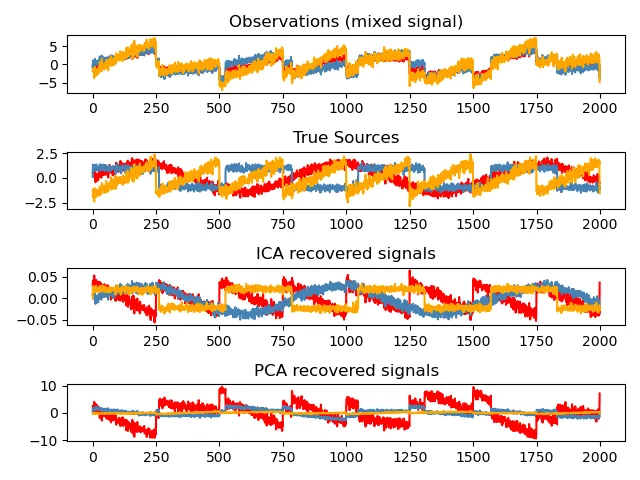

Источник: [хэндбук по ML от Яндекса](https://education.yandex.ru/handbook/ml/article/matrichnaya-faktorizaciya)

Анализ независимых компонентов (ICA) - это метод оценки независимых исходных сигналов из набора записей, в которых исходные сигналы были смешаны в неизвестных соотношениях. Распространенным примером этого является проблема разделения слепых источников – коктейльная вечеринка

Интуиция ICA заключается в разделении изначального ЭЭГ сигнала на несколько независимых компонент, например: альфа-ритм, шум, небольшая наводка и тд.

ICA можно разделить на следующие шаги:

1. Отбеливание с PCA:

   - Нормализация каналов
   - PCA: выбирает компоненты согласно n_components (или доли дисперсии, напр. 0.95)

2. ICA декомпозиция:

   - На вход подаются топ-компоненты из PCA
   - На выходе получаем независимые компоненты

3. Реконструкция (ica.apply()):

   - Берет все независимые компоненты кроме exclude и остатка PCA и реконструирует сигнал


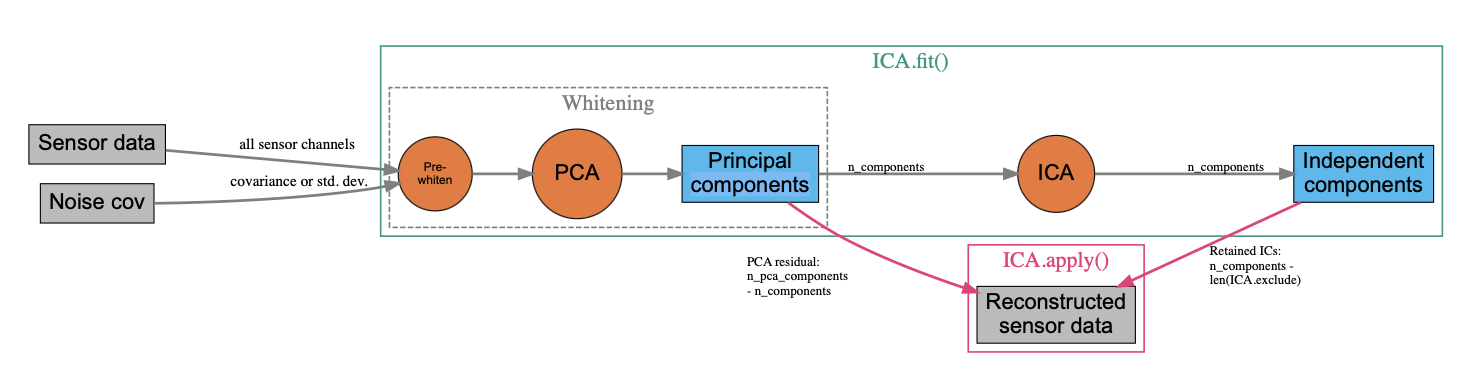

Источник: [Метод независимых компонент](https://cmi.to/анализ-ээг/методы-анализа-ээг/методы-компьютерного-анализа-ээг/метод-независимых-компонент/)

MNE-Python реализует три различных алгоритма ICA:
- fastICA (по умолчанию)
- picard
- infomax

FastICA и Infomax довольно широко используются; Picard — более новый (2017 г.) алгоритм, который, как ожидается, сходится быстрее, чем FastICA и Infomax, и более устойчив, чем другие алгоритмы, в случаях, когда источники не полностью независимы, что обычно происходит с реальными данными ЭЭГ/МЭГ

In [ ]:
regexp = r"(MEG [12]5[13]1)"
artifact_picks = mne.pick_channels_regexp(raw.ch_names, regexp=regexp)
raw.plot(order=artifact_picks, n_channels=len(artifact_picks), show_scrollbars=False);

Прежде чем мы запускать ICA, важным шагом является фильтрация данных для устранения низкочастотных дрейфов, которые могут негативно повлиять на качество подгонки ICA. Медленные дрейфы являются проблематичными, потому что они снижают независимость предполагаемых независимых источников (например, сердцебиение или другие мышечные источники, как правило, имеют более высокие значения), что затрудняет алгоритму поиск точного решения.

Рекомендуется профильтровать данные с высокими частотами с частотой отсечки 1 Гц

In [ ]:
filt_raw = raw.copy().filter(l_freq=1.0, h_freq=None).pick(picks=["mag", "eeg", "eog"])

Теперь мы готовы запустить ICA. Поскольку мы знаем (на основе анализа исходных данных), что артефакты ЭКГ довольно сильны, мы ожидаем, что эти артефакты будут зафиксированы в первых компонентах разложения PCA, которое происходит до ICA (хотя обычно предпочтительнее включить больше компонентов для более точного решения).


In [ ]:
from mne.preprocessing import ICA

ica = ICA(method='fastica', n_components=15, max_iter="auto", random_state=97)
ica.fit(filt_raw)
ica

In [ ]:
print(f"Доля объясненной дисперсии по МЭГ каналам: {ica.get_explained_variance_ratio(filt_raw).get('mag')}")

In [ ]:
ica.plot_components();

In [ ]:
ica.plot_sources(filt_raw, show_scrollbars=False);

In [ ]:
ica.plot_sources(raw, show_scrollbars=False);

In [ ]:
# ЭОГ
ica.plot_overlay(raw, exclude=[0], picks="eeg");

In [ ]:
# ЭКГ
ica.plot_overlay(raw, exclude=[2], picks="mag");

In [ ]:
ica.plot_properties(raw, picks=[0]);

In [ ]:
reconst_raw = raw.copy()
ica.apply(reconst_raw, exclude = [0,2]);

In [ ]:
raw.plot(order=artifact_picks, n_channels=len(artifact_picks), show_scrollbars=False);

In [ ]:
reconst_raw.plot(
    order=artifact_picks, n_channels=len(artifact_picks), show_scrollbars=False
);
#del reconst_raw

#### Отличие PCA от ICA:

- Цель:

PCA ищет ортогональные компоненты, которые максимизируют дисперсию данных (наилучшее представление структуры). ICA ищет компоненты, которые максимально статистически независимы друг от друга (разделение сигналов).

- Статистические свойства:

PCA декоррелирует данные (устраняет корреляцию), но не учитывает высшие порядки зависимостей. ICA устраняет как корреляцию, так и высшие порядки зависимостей (независимость).

- Ортогональность:

Компоненты PCA всегда ортогональны (перпендикулярны) друг другу. Компоненты ICA не обязательно ортогональны.

- Упорядоченность:

В PCA компоненты упорядочены по убыванию дисперсии (первая компонента важнее второй). В ICA все компоненты считаются равнозначными.

- Распределение:

ICA предполагает, что источники имеют распределение, отличное от нормального (негауссово), в то время как PCA не делает таких предположений.

- Применение:

PCA лучше всего подходит для сжатия данных, снижения размерности и удаления шума. ICA эффективнее для слепого разделения источников (например, отделение сигнала от шума или выделение артефактов в ЭЭГ)

#### Полезные ссылки

- Анализ независимых компонент Вики: https://ru.wikipedia.org/wiki/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%BD%D0%B5%D0%B7%D0%B0%D0%B2%D0%B8%D1%81%D0%B8%D0%BC%D1%8B%D1%85_%D0%BA%D0%BE%D0%BC%D0%BF%D0%BE%D0%BD%D0%B5%D0%BD%D1%82
- Метод независимых компонент: https://cmi.to/анализ-ээг/методы-анализа-ээг/методы-компьютерного-анализа-ээг/метод-независимых-компонент/
- ЭЭГ. Анализ независимых компонентов (ICA): https://dzen.ru/a/YW_TNIe9gWU4r91M
- Repairing artifacts with ICA: https://mne.tools/stable/auto_tutorials/preprocessing/40_artifact_correction_ica.html
- `mne.preprocessing.ICA`: https://mne.tools/stable/generated/mne.preprocessing.ICA.html

### 4. Signal-to-Noise Ratio (SNR)

Signal-to-Noise Ratio – это отношение мощности полезного сигнала к мощности шума, поэтому и переводится как отношение сигнал/шум. По сути это мера величина для оценки качества предобработки данных

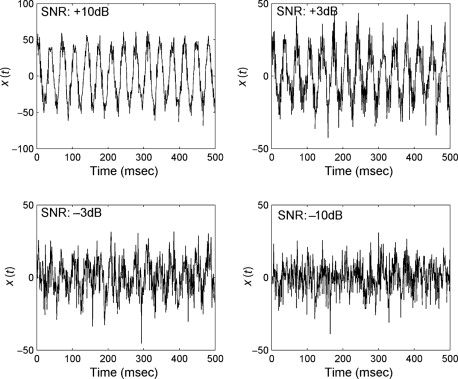

Источник: [Signal to Noise Ratios](https://www.sciencedirect.com/topics/social-sciences/signal-to-noise-ratios)

Интуиция:

Представьте разговор в шумном баре. Если голос друга громкий, а фоновая музыка тихая — SNR высокий (вы всё понимаете). Если музыка громкая, а друг шепчет — SNR низкий (слышен только шум)

В технике мощности сигналов могут различаться в миллионы раз (например, от микровольта до сотен вольт). Оперировать огромными числами неудобно.
Децибелы (дБ) переводят кратное увеличение в логарифмическую шкалу, превращая умножение в сложение, а огромные числа — в компактные

```python
SNR = P_signal / P_noise
SNR_dB = 10 * log10(P_signal / P_noise)
```
Чем больше дБ, тем лучше:
- SNR = 10 дБ: сигнал в 10 раз мощнее шума
- SNR = 20 дБ: сигнал в 100 раз мощнее шума  
- SNR = 0 дБ: сигнал = шум (неразличимы)



In [ ]:
snr_db = 10 # шум (SNR = 10 дБ)
fs = 256
t = np.arange(0, 10, 1/fs)  # 10 секунд
f_alpha = 10  # Альфа ритм 10 Гц

alpha_clean = np.sin(2 * np.pi * f_alpha * t)

power_signal = np.var(alpha_clean)
power_noise = power_signal / (10**(snr_db/10))
noise = np.random.normal(0, np.sqrt(power_noise), t.shape)
alpha_noisy = alpha_clean + noise

def compute_snr(signal, noise):
    if np.all(noise) == 0:
        return np.inf
    return 10 * np.log10(np.var(signal) / np.var(noise))

snr_clean = compute_snr(alpha_clean, 0)
snr_noisy = compute_snr(alpha_clean, noise)

print(f"SNR чистого сигнала: {snr_clean:.1f} дБ")
print(f"SNR с шумом: {snr_noisy:.1f} дБ")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(t[:int(2*fs)], alpha_clean[:int(2*fs)], 'b',
             label=f'Чистый альфа (SNR = {snr_clean:.0f} дБ)', linewidth=2)
axes[0].set_title('Чистый альфа ритм')
axes[0].set_ylabel('Амплитуда')
axes[0].legend()

axes[1].plot(t[:int(2*fs)], alpha_noisy[:int(2*fs)], 'r',
             label=f'Альфа + шум (SNR = {snr_noisy:.0f} дБ)', linewidth=2)
axes[1].set_title('Альфа ритм с шумом')
axes[1].set_xlabel('Время (с)')
axes[1].set_ylabel('Амплитуда')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
psds, freqs = raw.compute_psd(fmin=0, fmax=40, picks='eeg').get_data(return_freqs=True)

alpha_mask = (freqs >= 8) & (freqs <= 13)
noise_mask = (~alpha_mask) & (freqs < 40)

signal_power = psds[:, alpha_mask].sum(axis=1)
noise_power = psds[:, noise_mask].sum(axis=1)

snr_freq = 10 * np.log10(signal_power / noise_power)
print(f"\nСпектральный SNR (альфа): {np.mean(snr_freq):.1f} ± {np.std(snr_freq):.1f} дБ")

In [ ]:
psds, freqs = reconst_raw.compute_psd(fmin=0, fmax=40, picks='eeg').get_data(return_freqs=True)

alpha_mask = (freqs >= 8) & (freqs <= 13)
noise_mask = (~alpha_mask) & (freqs < 40)

signal_power = psds[:, alpha_mask].sum(axis=1)
noise_power = psds[:, noise_mask].sum(axis=1)

snr_freq = 10 * np.log10(signal_power / noise_power)
print(f"\nСпектральный SNR (альфа) для отфильтрованных данных: {np.mean(snr_freq):.1f} ± {np.std(snr_freq):.1f} дБ")

In [ ]:
filt_raw = raw.copy().filter(l_freq=9.0, h_freq=12).pick(picks=["eeg"])

psds, freqs = filt_raw.compute_psd(fmin=0, fmax=40, picks='eeg').get_data(return_freqs=True)

alpha_mask = (freqs >= 8) & (freqs <= 13)
noise_mask = (~alpha_mask) & (freqs < 40)

signal_power = psds[:, alpha_mask].sum(axis=1)
noise_power = psds[:, noise_mask].sum(axis=1)

snr_freq = 10 * np.log10(signal_power / noise_power)
print(f"\nСпектральный SNR (альфа) для отфильтрованных данных: {np.mean(snr_freq):.1f} ± {np.std(snr_freq):.1f} дБ")

#### Полезные ссылки

- Отношение сигнал/шум Вики: https://ru.wikipedia.org/wiki/Отношение_сигнал/шум
- Signal to Noise Ratios: https://www.sciencedirect.com/topics/social-sciences/signal-to-noise-ratios
- Frequency-tagging: Basic analysis of an SSVEP/vSSR dataset: https://mne.tools/1.0/auto_tutorials/time-freq/50_ssvep.html#extract-snr-values-at-the-stimulation-frequency

---

## Небольшой конспект по ноутбуку «Удаление артефактов, ICA»

---

### 1. Артефакты в ЭЭГ

Артефакты в ЭЭГ — это нежелательные сигналы, регистрируемые при ЭЭГ и не связанные с мозговой активностью. Чаще всего они делятся на:
- физиологические (активность глаз, мышц, сердца и тд.)
- физические (сетевая наводка 50/60 Гц, движение электродов и тд.)

#### Основные типы физических артефактов:

1. **Проблемы с электродом**
- Частота: широкий спектр
- Каналы: все
- Признаки: отсутствие сигнала или какой-то шум с большими скачками
- Методы устранения: пометка bad channels

#### Примеры использования:
```python
ptp_threshold = {
    'eeg': 75e-7
}

annotations, bad_channels = mne.preprocessing.annotate_amplitude(
    raw,
    peak=ptp_threshold,
)

raw_ann.set_annotations(annotations)
```

2. **Сетевая наводка**
- Частота: `50/60 Гц`
- Каналы: все
- Признаки: регулярные колебания правильной синусоидной формы частотой 50 Гц в России и СНГ или 60 Гц в некоторых странах (например, США)
- Методы устранения: Notch filter на 50/60 Гц


#### Примеры использования:
```python
raw.copy().notch_filter(freqs=[60,120,180,240])
```

#### Основные типы физиологических артефактов:

1. **Движение тела**
- Частота: широкий спектр
- Каналы: все
- Признаки: резкие скачки по амплитуде
- Методы устранения: reject bad epochs

#### Примеры использования:
```python
reject_criteria = {
    'eeg': 500e-6
}

epochs = mne.Epochs(
    ...
    reject=reject_criteria,  # Отбрасывает epochs с артефактами
    reject_tmin=-0.1, reject_tmax=0.3, # Только в этом окне проверяем
)
```

2. **Мышцы (ЭМГ)**
- Частота: `>30 Гц`
- Каналы: фронтальные и виски
- Признаки: высокочастотный шум
- Методы устранения: фильтр >40 Гц

#### Примеры использования:
```python
raw_bp = raw.copy().filter(l_freq=1, h_freq=40, picks='eeg')
```

3. **Глаза (ЭОГ)**

- Частота: `<4 Гц`
- Каналы: фронтальные, например, `Fp1/Fp2`
- Признаки: резкие пики
- Методы устранения: ICA

4. **Сердце (ЭКГ)**
- Частота: `~1 Гц`
- Каналы: все
- Признаки: ритмичные пики, похожие на ЭКГ
- Методы устранения: ICA


#### Полезные ссылки
- Подробно про типы артефактов в ЭЭГ: https://cmi.to/%D0%B0%D1%80%D1%82%D0%B5%D1%84%D0%B0%D0%BA%D1%82%D1%8B/
- Overview of artifact detection: https://mne.tools/stable/auto_tutorials/preprocessing/10_preprocessing_overview.html
- Repairing artifacts with SSP: https://mne.tools/stable/auto_tutorials/preprocessing/50_artifact_correction_ssp.html
- Repairing artifacts with regression: https://mne.tools/stable/auto_tutorials/preprocessing/35_artifact_correction_regression.html


---


### 2. Метод главных компонент

**Метод главных компонент (PCA)** — это метод снижения размерности, который можно использовать и для удаления артефактов, так как он:

- Находит коррелированные компоненты между каналами
- Сортирует их по важности (дисперсии)
- Позволяет удалить артефакты (чаще всего последние компоненты по важности), сохранив мозговую активность
- Используется как первый шаг в ICA

Примеры применения в ЭЭГ:

1. Удаление артефактов (ЭОГ, ЭМГ)
2. Сжатие данных (60 каналов -> 10 главных компонент)
3. Выделение пространственных паттернов


#### Примеры использования:
```python
from sklearn.decomposition import PCA

data, times = raw.get_data(stop=int(10*raw.info['sfreq']), return_times=True)

data = data[:10, :]

# PCA (центрирование + преобразование)
pca = PCA(n_components=5)  # 5 главных компонент
pca_data = pca.fit_transform(data.T)  # Транспонируем: samples × features

print("Объясненная дисперсия:", pca.explained_variance_ratio_)
print("Общая объясненная дисперсия:", pca.explained_variance_ratio_.sum())
```

#### Интуиция работы PCA

Представьте, что ЭЭГ — это комната, полная людей (электродов), которые одновременно кричат (сигналы). Вы хотите понять, кто кричит громче всего.

- Шаг 1: Центрируем сигнал, вычитая среднее по времени или по наблюдениям, чтобы обеспечить корректное вычисление ковариационной матрицы и интерпретацию дисперсии. Ковариация по определению измеряет совместные отклонения двух признаков от их средних значений. Если среднее не вычтено, формулы фактически «считают» взаимосвязь между абсолютными уровнями сигнала, а не их флуктуациями
- Шаг 2: PCA ищет линейную комбинацию всех каналов, которая объясняет самую большую часть изменчивости (дисперсии) данных. PC1 – главная компонента, которая обычно захватывает самый сильный и распространенный сигнал — например, артефакт движения или сильный ритм (альфа-ритм), видимый на многих каналах сразу.
- Шаг 3: Ортогонализация (поиск нового, независимого). PCA находит следующую компоненту (PC2), которая описывает оставшуюся дисперсию, но при этом математически ортогональна (не коррелирует, 90 градусов) к первой.

**Результат:** набор компонент, где PC1 — самая важная комопнента, PC2 — слабее, и т.д.

**Важно:** тут компоненты упорядочены по энергии, но это не обязательно соответствует физическим источникам в мозге

**Ограничения:** PCA — это линейный метод. В тех случаях, когда зависимость между признаками ЭЭГ нелинейна, могут потребоваться модификации, например Kernel PCA.

#### Полезные ссылки

- Метод главных компонент: https://ru.wikipedia.org/wiki/%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%B3%D0%BB%D0%B0%D0%B2%D0%BD%D1%8B%D1%85_%D0%BA%D0%BE%D0%BC%D0%BF%D0%BE%D0%BD%D0%B5%D0%BD%D1%82
- Как работает метод главных компонент (PCA) на простом примере: https://habr.com/ru/articles/304214/
- Principal Component Analysis (PCA): https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-pca/
- Метод главных компонент (PCA). Принцип работы и реализация с нуля на Python: https://habr.com/ru/articles/799001/
- Метод главных компонент: что это, применение: https://practicum.yandex.ru/blog/metod-glavnyh-komponent/

---

### 3. Метод независимых компонент (ICA)

Independent Component Analysis (ICA) - это метод оценки независимых исходных сигналов из набора записей, в которых исходные сигналы были смешаны в неизвестных соотношениях. Распространенным примером этого является проблема разделения слепых источников – коктейльная вечеринка

Интуиция ICA заключается в разделении изначального ЭЭГ сигнала на несколько независимых компонент, например: альфа-ритм, шум, небольшая наводка и тд.

ICA можно разделить на следующие шаги:

1. Отбеливание с PCA:
   • Нормализация каналов
   • PCA: выбирает компоненты согласно n_components (или доли дисперсии, напр. 0.95)

2. ICA декомпозиция:
   • На вход подаются топ-компоненты из PCA
   • На выходе получаем независимые компоненты

3. Реконструкция (ica.apply()):
   • Берет все независимые компоненты кроме exclude и остатка PCA и реконструирует сигнал

#### Отличие PCA от ICA:

- Цель:

PCA ищет ортогональные компоненты, которые максимизируют дисперсию данных (наилучшее представление структуры). ICA ищет компоненты, которые максимально статистически независимы друг от друга (разделение сигналов).

- Статистические свойства:

PCA декоррелирует данные (устраняет корреляцию), но не учитывает высшие порядки зависимостей. ICA устраняет как корреляцию, так и высшие порядки зависимостей (независимость).

- Ортогональность:

Компоненты PCA всегда ортогональны (перпендикулярны) друг другу. Компоненты ICA не обязательно ортогональны.

- Упорядоченность:

В PCA компоненты упорядочены по убыванию дисперсии (первая компонента важнее второй). В ICA все компоненты считаются равнозначными.

- Распределение:

ICA предполагает, что источники имеют распределение, отличное от нормального (негауссово), в то время как PCA не делает таких предположений.

- Применение:

PCA лучше всего подходит для сжатия данных, снижения размерности и удаления шума. ICA эффективнее для слепого разделения источников (например, отделение сигнала от шума или выделение артефактов в ЭЭГ)

#### Пример использования:

```python
raw.filter(1, 40, picks='mag')  # MEG магнитометры, 1-40 Гц
raw.crop(tmax=60)  # 60 секунд для скорости

ica = ICA(n_components=0.95, method='fastica', random_state=42)
ica.fit(raw, picks='mag')

ica.plot_components()
```

```python
ica.exclude = [1, 2]  # Исключаем IC1, IC2
raw_clean = raw.copy()
ica.apply(raw_clean)
```

#### Полезные ссылки

- Анализ независимых компонент Вики: https://ru.wikipedia.org/wiki/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%BD%D0%B5%D0%B7%D0%B0%D0%B2%D0%B8%D1%81%D0%B8%D0%BC%D1%8B%D1%85_%D0%BA%D0%BE%D0%BC%D0%BF%D0%BE%D0%BD%D0%B5%D0%BD%D1%82
- Метод независимых компонент: https://cmi.to/анализ-ээг/методы-анализа-ээг/методы-компьютерного-анализа-ээг/метод-независимых-компонент/
- ЭЭГ. Анализ независимых компонентов (ICA): https://dzen.ru/a/YW_TNIe9gWU4r91M
- Repairing artifacts with ICA: https://mne.tools/stable/auto_tutorials/preprocessing/40_artifact_correction_ica.html
- `mne.preprocessing.ICA`: https://mne.tools/stable/generated/mne.preprocessing.ICA.html

---

### Signal-to-Noise Ratio (SNR)

Signal-to-Noise Ratio (отношение сигнал/шум) – это отношение мощности полезного сигнала к мощности шума, поэтому и переводится как отношение сигнал/шум. По сути это мера величина для оценки качества предобработки данных

Интуиция:

Представьте разговор в шумном баре. Если голос друга громкий, а фоновая музыка тихая — SNR высокий (вы всё понимаете). Если музыка громкая, а друг шепчет — SNR низкий (слышен только шум)

В технике мощности сигналов могут различаться в миллионы раз (например, от микровольта до сотен вольт). Оперировать огромными числами неудобно.
Децибелы (дБ) переводят кратное увеличение в логарифмическую шкалу, превращая умножение в сложение, а огромные числа — в компактные

#### Пример использования
```python
SNR = P_signal / P_noise
SNR_dB = 10 * log10(P_signal / P_noise)
```
Чем больше дБ, тем лучше:
- SNR = 10 дБ: сигнал в 10 раз мощнее шума
- SNR = 20 дБ: сигнал в 100 раз мощнее шума  
- SNR = 0 дБ: сигнал = шум (неразличимы)

#### Полезные ссылки

- Отношение сигнал/шум Вики: https://ru.wikipedia.org/wiki/Отношение_сигнал/шум
- Signal to Noise Ratios: https://www.sciencedirect.com/topics/social-sciences/signal-to-noise-ratios
- Frequency-tagging: Basic analysis of an SSVEP/vSSR dataset: https://mne.tools/1.0/auto_tutorials/time-freq/50_ssvep.html#extract-snr-values-at-the-stimulation-frequency

